# Agentic Router RAG with LangGraph

In this notebook, we'll build an agentic RAG system that can route queries to the appropriate data source, including web search for current information. This solves some of the limitations we saw in the basic RAG approach.

## What is Agentic Router RAG?

Router RAG adds an intelligent routing layer that:
1. **Analyzes the query** to understand the user's intent
2. **Routes to the appropriate data source** (catalog, FAQ, troubleshooting, or web search)
3. **Retrieves relevant documents** from the correct collection or searches the web
4. **Generates contextual answers** using only relevant information

## Learning Objectives

By the end of this notebook, you will:
- Understand how query routing works in RAG systems
- Connect to multiple ChromaDB collections, for different types of data
- Integrate web search for current information using Tavily
- Build a router node that classifies query intent
- Create conditional workflows in LangGraph
- Compare router RAG performance with basic RAG

## Setup and Imports

We'll need additional imports for the router functionality and structured output.

In [ ]:
import os
from pathlib import Path
from typing import List, TypedDict, Literal

from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from IPython.display import Image, display

# Load environment variables
load_dotenv()

print("All imports successful!")

## Environment Setup

Check for required environment variables.

In [ ]:
# Check if Azure OpenAI API key is available
azure_openai_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if not azure_openai_api_key:
    raise ValueError("AZURE_OPENAI_API_KEY environment variable is required")

# Check if Tavily API key is available
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key:
    raise ValueError("TAVILY_API_KEY environment variable is required for web search functionality")

print("Azure OpenAI API key found!")
print("Tavily API key found!")

## Understanding Our Separate Collections

Unlike the basic RAG notebook, we now have three separate ChromaDB collections:

1. **techmart_catalog**: Product information, specifications, and descriptions
2. **techmart_faq**: Customer service questions about shipping, returns, policies
3. **techmart_troubleshooting**: Technical support guides and solutions

Each collection contains documents optimized for its specific domain.

## Connect to Separate ChromaDB Collections

We'll create three separate vector store instances, one for each collection.

In [ ]:
# Initialize embeddings model (same as used during ingestion)
embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment="text-embedding-3-large_1",
    api_version="2024-02-01",
    api_key=azure_openai_api_key,
)

# Path to the separate ChromaDB collections
chroma_db_path = Path("..") / "vector_store" / "chroma_db_separate"

# Connect to each collection
catalog_store = Chroma(
    collection_name="techmart_catalog",
    embedding_function=embeddings,
    persist_directory=str(chroma_db_path)
)

faq_store = Chroma(
    collection_name="techmart_faq",
    embedding_function=embeddings,
    persist_directory=str(chroma_db_path)
)

troubleshooting_store = Chroma(
    collection_name="techmart_troubleshooting",
    embedding_function=embeddings,
    persist_directory=str(chroma_db_path)
)

print(f"Connected to separate ChromaDB collections at: {chroma_db_path}")
print(f"Catalog collection: {catalog_store._collection.count()} documents")
print(f"FAQ collection: {faq_store._collection.count()} documents")
print(f"Troubleshooting collection: {troubleshooting_store._collection.count()} documents")

## Test Each Collection

Let's verify each collection contains the expected type of information.

In [4]:
# Test each collection with a relevant query
test_queries = {
    "catalog": "laptop with good performance",
    "faq": "shipping times", 
    "troubleshooting": "battery drain problem"
}

stores = {
    "catalog": catalog_store,
    "faq": faq_store,
    "troubleshooting": troubleshooting_store
}

for collection_name, query in test_queries.items():
    store = stores[collection_name]
    results = store.similarity_search(query, k=2)
    
    print(f"\n{collection_name.upper()} Collection - Query: '{query}'")
    print("=" * 60)
    for i, doc in enumerate(results, 1):
        print(f"Document {i}: {doc.page_content[:150]}...")
    print("-" * 60)


CATALOG Collection - Query: 'laptop with good performance'
Document 1: product_id: SKU232 | name: ZenithBook 11 Evo | category: Laptop | price: 1299.0 | short_desc: A sleek 15-inch ultrabook with Intel Core i7, 16GB RAM, ...
Document 2: product_id: SKU050 | name: ZenithBook 15 Evo | category: Laptop | price: 1299.0 | short_desc: 15.6" ultralight laptop with Intel Core i7, 16GB RAM, sp...
------------------------------------------------------------

FAQ Collection - Query: 'shipping times'
Document 1: question: How long does standard shipping take within the continental US? | answer: Standard shipping typically arrives in 3–5 business days once your...
Document 2: question: Do you offer next‑day delivery for laptops? | answer: Yes, we offer overnight delivery on all in‑stock laptops for orders placed before 2 p....
------------------------------------------------------------

TROUBLESHOOTING Collection - Query: 'battery drain problem'
Document 1: issue_title: UltraBook Pro battery drai


FAQ Collection - Query: 'shipping times'
Document 1: question: How long does standard shipping take within the continental US? | answer: Standard shipping typically arrives in 3–5 business days once your...
Document 2: question: Do you offer next‑day delivery for laptops? | answer: Yes, we offer overnight delivery on all in‑stock laptops for orders placed before 2 p....
------------------------------------------------------------



TROUBLESHOOTING Collection - Query: 'battery drain problem'
Document 1: issue_title: UltraBook Pro battery drains quickly | product_id: SKU001 | symptoms: Battery indicator drops from 100 % to 70 % in under an hour of web ...
Document 2: issue_title: Zenith X5 battery drains overnight | product_id: SKU014 | symptoms: Battery drops 20 % while idle on standby. | steps: 1. Disable ‘Always...
------------------------------------------------------------


## Initialize Language Models

We'll use separate Azure OpenAI models for routing decisions and answer generation. This flexibility in an agentic RAG workflow gives us an opportunity to optimise cost and latency while making sure the performance of the overall system remains optimal.

In [ ]:
# Initialize the language model for generating answers
generation_llm = AzureChatOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment="gpt-4o_2024-05-13",
    api_version="2024-02-01",
    api_key=azure_openai_api_key,
)
print(f"Answer generation language model initialized: {generation_llm.model_name}")

# Initialize the language model for routing decisions
routing_llm = AzureChatOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment="gpt-4o_2024-05-13",
    api_version="2024-02-01",
    api_key=azure_openai_api_key,
)
print(f"Routing language model initialized: {routing_llm.model_name}")

## Define Router Output Schema

We'll use Pydantic to define the structure of our router's output, ensuring it always returns one of our three valid collection names.

In [6]:
class RouterOutput(BaseModel):
    """Output schema for the query router."""
    chosen_collection: Literal["catalog", "faq", "troubleshooting", "web_search"] = Field(
        description="The collection to route the query to based on intent"
    )
    reasoning: str = Field(
        description="Brief explanation of why this collection was chosen"
    )

print("Router output schema defined!")

Router output schema defined!


## Create Router Prompt Template

This prompt will guide the LLM to classify queries and route them to the appropriate collection.

In [7]:
# Router prompt for query classification
router_prompt = ChatPromptTemplate.from_template(
    """You are a query router for TechMart, an electronics retailer. 
Analyze the user's query and determine which collection contains the most relevant information.

Collections available:
- **catalog**: Product information, specifications recommendations, comparisons, and technical details about laptops, desktops, monitors, and accessories
- **faq**: Customer service questions about shipping, delivery, returns, warranties, policies, and general business operations
- **troubleshooting**: Technical support guides, problem diagnosis, step-by-step solutions, and fixes for product issues that TechMart sells
- **web_search**: For questions about issues that are not covered in our internal troubleshooting database, or for getting the latest information about software, hardware, drivers, or anything that require current information from the internet

Query: {query}

Instructions:
- Choose the single most appropriate collection for this query
- If a query spans multiple domains, choose the primary intent
- Use web_search for troubleshooting issues that are likely not covered in our limited internal database
- Provide brief reasoning for your choice

Examples:
- "What laptops do you recommend?" → catalog (product recommendations)
- "How long does shipping take?" → faq (shipping policy)
- "My laptop won't turn on" → troubleshooting (common technical problem we likely have guides for)
- "Best gaming desktop under $2000" → catalog (product search with specs)
- "Can I return a monitor?" → faq (return policy)
- "Headphones keep disconnecting" → troubleshooting (common connectivity issue)
- "Windows 11 blue screen error 0x0000007E" → web_search (specific system error requiring current information)
- "How to fix Chrome crashes on latest macOS" → web_search (software issue needing current solutions)
- "Latest NVIDIA driver causing display issues" → web_search (current driver problem not in our database)
- "WiFi adapter not working after Windows update" → web_search (current OS compatibility issue)
"""
)

# Create router chain with structured output
router_chain = router_prompt | routing_llm.with_structured_output(RouterOutput)

print("Router prompt and chain created!")

Router prompt and chain created!


## Test the Router

Let's test our router with different types of queries to see how it classifies them.

In [8]:
# Test queries for each collection type including web search
test_router_queries = [
    "Tell me about the UltraBook battery",
    "How long does international shipping take?",
    "Laptop battery drains too quickly",
    "Windows 11 blue screen error 0x0000007E",
    "What's the latest Nvidia GPU for gaming?",
]

print("Testing Router Decisions (Including Web Search):")
print("=" * 70)

for query in test_router_queries:
    result = router_chain.invoke({"query": query})
    print(f"Query: {query}")
    print(f"  → Collection: {result.chosen_collection}")
    print(f"  → Reasoning: {result.reasoning}")
    print()

Testing Router Decisions (Including Web Search):
Query: Tell me about the UltraBook battery
  → Collection: catalog
  → Reasoning: The user is asking for information about a product feature/specification (the UltraBook battery), which fits product details and technical information in the catalog.

Query: How long does international shipping take?
  → Collection: faq
  → Reasoning: The query asks about international shipping time, which is a customer service/shipping policy question best covered by the FAQ collection.

Query: Laptop battery drains too quickly
  → Collection: troubleshooting
  → Reasoning: The query describes a common laptop hardware issue (rapid battery drain) and is best handled by internal technical support guides for diagnosing and fixing battery problems.

Query: Windows 11 blue screen error 0x0000007E
  → Collection: web_search
  → Reasoning: This is a specific Windows 11 blue screen stop code issue that likely requires up-to-date troubleshooting steps and may not 

Query: Tell me about the UltraBook battery
  → Collection: catalog
  → Reasoning: The query is asking for information about the UltraBook battery, which is a product detail/specification rather than a support or policy question.



Query: How long does international shipping take?
  → Collection: faq
  → Reasoning: The query asks about shipping timeframe, which is a customer service/shipping policy question best covered by the FAQ collection.



Query: Laptop battery drains too quickly
  → Collection: troubleshooting
  → Reasoning: The query describes a common laptop battery issue and is best handled by technical support steps and diagnosis guides in the troubleshooting collection.



Query: Windows 11 blue screen error 0x0000007E
  → Collection: web_search
  → Reasoning: This is a specific Windows 11 blue screen error code, which is likely to require current, external troubleshooting information rather than a general internal guide.



Query: What's the latest Nvidia GPU for gaming?
  → Collection: web_search
  → Reasoning: The query asks for the latest Nvidia GPU, which requires current up-to-date product information rather than static catalog, FAQ, or troubleshooting content.



## Define State for Router RAG

Our state needs to track the query, routing decision, retrieved documents, and final answer.

In [9]:
class RouterRAGState(TypedDict):
    """State for our Router RAG workflow."""
    query: str
    chosen_collection: str
    routing_reasoning: str
    retrieved_docs: List[Document]
    answer: str

print("Router RAG state defined!")

Router RAG state defined!


## Create Router Node

The router node analyzes the query and determines which collection to search.

In [10]:
def query_router(state: RouterRAGState) -> RouterRAGState:
    """Route query to the appropriate collection based on intent."""
    query = state["query"]
    
    # Use the router chain to classify the query
    router_result = router_chain.invoke({"query": query})
    
    print(f"Router Decision: {router_result.chosen_collection}")
    print(f"Reasoning: {router_result.reasoning}")
    
    return {
        "chosen_collection": router_result.chosen_collection,
        "routing_reasoning": router_result.reasoning
    }

print("Router node created!")

Router node created!


## Create Retrieve Nodes

We'll create separate retrieve nodes for each collection.

In [11]:
# Initialize Tavily search for web search
tavily_search = TavilySearch(
    max_results=5,  # Number of search results to return
    tavily_api_key=tavily_api_key,
)

def retrieve_from_catalog(state: RouterRAGState) -> RouterRAGState:
    """Retrieve documents from the product catalog."""
    query = state["query"]
    retrieved_docs = catalog_store.similarity_search(query, k=5)
    
    # Print first 100 characters of each retrieved document with source
    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        content_preview = doc.page_content[:100]
        print(f"  Doc {i} [{source}]: {content_preview}...")
    
    print(f"Retrieved {len(retrieved_docs)} documents from catalog")
    return {"retrieved_docs": retrieved_docs}

def retrieve_from_faq(state: RouterRAGState) -> RouterRAGState:
    """Retrieve documents from the FAQ collection."""
    query = state["query"]
    retrieved_docs = faq_store.similarity_search(query, k=5)
    
    # Print first 100 characters of each retrieved document with source
    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        content_preview = doc.page_content[:100]
        print(f"  Doc {i} [{source}]: {content_preview}...")
    
    print(f"Retrieved {len(retrieved_docs)} documents from FAQ")
    return {"retrieved_docs": retrieved_docs}

def retrieve_from_troubleshooting(state: RouterRAGState) -> RouterRAGState:
    """Retrieve documents from the troubleshooting collection."""
    query = state["query"]
    retrieved_docs = troubleshooting_store.similarity_search(query, k=5)
    
    # Print first 100 characters of each retrieved document with source
    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        content_preview = doc.page_content[:100]
        print(f"  Doc {i} [{source}]: {content_preview}...")
    
    print(f"Retrieved {len(retrieved_docs)} documents from troubleshooting")
    return {"retrieved_docs": retrieved_docs}

def retrieve_from_web_search(state: RouterRAGState) -> RouterRAGState:
    """Retrieve documents from web search using Tavily."""
    query = state["query"]
    
    # Use Tavily to search the web, then convert the results into Document objects
    search_response = tavily_search.invoke({"query": query})
    retrieved_docs = [
        Document(
            page_content=result["content"],
            metadata={"source": result["url"], "title": result.get("title", "")},
        )
        for result in search_response.get("results", [])
    ]
    
    # Print first 100 characters of each retrieved document with source
    for i, doc in enumerate(retrieved_docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        content_preview = doc.page_content[:100]
        print(f"  Doc {i} [{source}]: {content_preview}...")
    
    print(f"Retrieved {len(retrieved_docs)} documents from web search")
    return {"retrieved_docs": retrieved_docs}

print("Retrieve nodes created!")
print("Tavily web search retriever initialized!")

Retrieve nodes created!
Tavily web search retriever initialized!


## Create Generate Node

The generate node creates answers using the retrieved documents from the selected collection.

In [12]:
# Enhanced prompt template for router RAG
generate_prompt = ChatPromptTemplate.from_template(
    """You are a helpful assistant for TechMart, an electronics retailer.
Use the following context from the {collection_type} database to answer the user's question accurately and helpfully.

Context from {collection_type}:
{context}

Question: {question}

Instructions:
- Base your answer primarily on the provided context from the {collection_type} database
- Be specific and helpful in your response
- If the context doesn't contain enough information, say so clearly
- Match your tone to the type of query (technical for troubleshooting, helpful for products, informative for policies)

Answer:"""
)

def generate_answer(state: RouterRAGState) -> RouterRAGState:
    """Generate answer based on retrieved documents."""
    query = state["query"]
    collection_type = state["chosen_collection"]
    retrieved_docs = state["retrieved_docs"]
    
    # Combine context from retrieved documents
    context_text = "\n\n".join([
        f"Source: {doc.metadata.get('source', 'Unknown')}\nContent: {doc.page_content}"
        for doc in retrieved_docs
    ])
    
    # Generate response
    messages = generate_prompt.invoke({
        "context": context_text,
        "question": query,
        "collection_type": collection_type
    })
    
    response = generation_llm.invoke(messages)
    
    print(f"Generated answer using {collection_type} collection")
    return {"answer": response.content}

print("Generate node created!")

Generate node created!


## Build the Router RAG Graph

Now we'll create our LangGraph with conditional routing based on the router's decision.

In [13]:
# Define routing function for conditional edges
def route_to_collection(state: RouterRAGState) -> str:
    """Determine which retrieve node to call based on router decision."""
    collection = state["chosen_collection"]
    return f"retrieve_{collection}"

# Create the graph builder
graph_builder = StateGraph(RouterRAGState)

# Add all nodes
graph_builder.add_node("router", query_router)
graph_builder.add_node("retrieve_catalog", retrieve_from_catalog)
graph_builder.add_node("retrieve_faq", retrieve_from_faq)
graph_builder.add_node("retrieve_troubleshooting", retrieve_from_troubleshooting)
graph_builder.add_node("retrieve_web_search", retrieve_from_web_search)
graph_builder.add_node("generate", generate_answer)

# Set entry point
graph_builder.add_edge(START, "router")

# Add conditional edges from router to appropriate retrieve node
graph_builder.add_conditional_edges(
    "router",
    route_to_collection,
    {
        "retrieve_catalog": "retrieve_catalog",
        "retrieve_faq": "retrieve_faq", 
        "retrieve_troubleshooting": "retrieve_troubleshooting",
        "retrieve_web_search": "retrieve_web_search"
    }
)

# All retrieve nodes go to generate
graph_builder.add_edge("retrieve_catalog", "generate")
graph_builder.add_edge("retrieve_faq", "generate")
graph_builder.add_edge("retrieve_troubleshooting", "generate")
graph_builder.add_edge("retrieve_web_search", "generate")

# Generate is the end
graph_builder.add_edge("generate", END)

# Compile the graph
router_rag_graph = graph_builder.compile()

print("Router RAG graph compiled successfully!")
print("Workflow: router -> [conditional] retrieve_[collection|web_search] -> generate")

Router RAG graph compiled successfully!
Workflow: router -> [conditional] retrieve_[collection|web_search] -> generate


## Visualize the Router RAG Graph

Let's visualize our router RAG workflow to see how the conditional routing works.

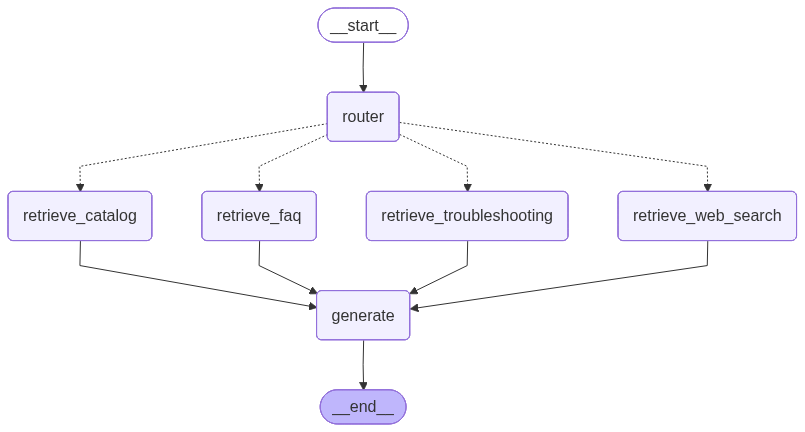

In [14]:
from IPython.display import Image, display

display(Image(router_rag_graph.get_graph().draw_mermaid_png()))

## Test the Complete Router RAG System

Let's test our router RAG system with various types of queries.

In [15]:
def ask_router_rag(query: str):
    """Ask a question to our Router RAG system."""
    print(f"\nQuery: {query}")
    print("=" * 70)
    
    # Run the router RAG workflow
    result = router_rag_graph.invoke({"query": query})
    
    print(f"\nAnswer: {result['answer']}")
    print("=" * 70)

In [16]:
# Test with a product recommendation query
ask_router_rag("I need a lightweight laptop for university. What do you recommend?")


Query: I need a lightweight laptop for university. What do you recommend?
Router Decision: catalog
Reasoning: The user is asking for a product recommendation for a lightweight laptop for university, which is a catalog-style query about product selection and specifications.
  Doc 1 [techmart_catalog.csv]: product_id: SKU254 | name: AeroLite 15 Slim Laptop | category: Laptop | price: 1249.0 | short_desc: ...
  Doc 2 [techmart_catalog.csv]: product_id: SKU028 | name: ZenLite 15 Evo Laptop | category: Laptop | price: 1199.0 | short_desc: Sl...
  Doc 3 [techmart_catalog.csv]: product_id: SKU050 | name: ZenithBook 15 Evo | category: Laptop | price: 1299.0 | short_desc: 15.6" ...
  Doc 4 [techmart_catalog.csv]: product_id: SKU164 | name: ZenithBook Air 13 | category: Laptop | price: 1199.0 | short_desc: Ultra-...
  Doc 5 [techmart_catalog.csv]: product_id: SKU306 | name: NeuraBook Air 13 | category: Laptop | price: 1199.0 | short_desc: Ultra-l...
Retrieved 5 documents from catalog
Generated 

Router Decision: catalog
Reasoning: The user is asking for a laptop recommendation based on a need (lightweight for university), which is a product selection request best served by catalog information.


  Doc 1 [techmart_catalog.csv]: product_id: SKU254 | name: AeroLite 15 Slim Laptop | category: Laptop | price: 1249.0 | short_desc: ...
  Doc 2 [techmart_catalog.csv]: product_id: SKU028 | name: ZenLite 15 Evo Laptop | category: Laptop | price: 1199.0 | short_desc: Sl...
  Doc 3 [techmart_catalog.csv]: product_id: SKU050 | name: ZenithBook 15 Evo | category: Laptop | price: 1299.0 | short_desc: 15.6" ...
  Doc 4 [techmart_catalog.csv]: product_id: SKU164 | name: ZenithBook Air 13 | category: Laptop | price: 1199.0 | short_desc: Ultra-...
  Doc 5 [techmart_catalog.csv]: product_id: SKU306 | name: NeuraBook Air 13 | category: Laptop | price: 1199.0 | short_desc: Ultra-l...
Retrieved 5 documents from catalog


Generated answer using catalog collection

Answer: For a lightweight university laptop, I’d recommend the **ZenithBook Air 13 (SKU164)**.

Why it stands out for university use:
- **Very light:** just **1.09 kg**
- **Good battery life:** up to **15 hours**
- **Portable 13.3" display:** **FHD+ IPS**, 400 nits, 100% sRGB
- **Solid everyday performance:** **Intel Core i5-1335U**, **16GB RAM**, **512GB storage**
- **Useful ports:** **2x Thunderbolt 4 USB-C**, **1x USB-A 3.2**, **microSD reader**, **3.5mm audio**

It’s priced at **$1199**.

Other lightweight options from the catalog:
- **NeuraBook Air 13 (SKU306)** — **1.1 kg**, **14-hour battery**, **$1199**
- **AeroLite 15 Slim Laptop (SKU254)** — **1.29 kg**, **13-hour battery**, larger **15.6"** screen, **$1249**
- **ZenLite 15 Evo Laptop (SKU028)** — **1.29 kg**, **12-hour battery**, **$1199**

If you want the **best balance of portability and battery**, I’d go with the **ZenithBook Air 13**. If you prefer a **larger screen for note-tak

In [17]:
# Test with a shipping policy query
ask_router_rag("How long does shipping take?")


Query: How long does shipping take?
Router Decision: faq
Reasoning: The query asks about shipping time, which is a customer service and delivery policy question best handled by the FAQ collection.
  Doc 1 [techmart_faq.csv]: question: How long does standard shipping take within the continental US? | answer: Standard shippin...
  Doc 2 [techmart_faq.csv]: question: How much does international shipping cost? | answer: International shipping starts at USD ...
  Doc 3 [techmart_faq.csv]: question: Can I track my package after it ships? | answer: Absolutely. A tracking link is emailed to...
  Doc 4 [techmart_faq.csv]: question: Do you offer next‑day delivery for laptops? | answer: Yes, we offer overnight delivery on ...
  Doc 5 [techmart_faq.csv]: question: When will I receive my refund? | answer: Refunds are processed 3–5 business days after we ...
Retrieved 5 documents from FAQ
Generated answer using faq collection

Answer: Shipping time depends on the shipping method and destination:

-

Router Decision: faq
Reasoning: The query asks about shipping time, which is a customer service and delivery policy question best handled by the FAQ collection.


  Doc 1 [techmart_faq.csv]: question: How long does standard shipping take within the continental US? | answer: Standard shippin...
  Doc 2 [techmart_faq.csv]: question: How much does international shipping cost? | answer: International shipping starts at USD ...
  Doc 3 [techmart_faq.csv]: question: Can I track my package after it ships? | answer: Absolutely. A tracking link is emailed to...
  Doc 4 [techmart_faq.csv]: question: Do you offer next‑day delivery for laptops? | answer: Yes, we offer overnight delivery on ...
  Doc 5 [techmart_faq.csv]: question: When will I receive my refund? | answer: Refunds are processed 3–5 business days after we ...
Retrieved 5 documents from FAQ


Generated answer using faq collection

Answer: Standard shipping within the continental US typically arrives in **3–5 business days** after your order has left our warehouse.

If you’d like, I can also share information about **international shipping**, **tracking**, or **next-day laptop delivery**.


In [18]:
# Test with a troubleshooting query
ask_router_rag("My laptop battery drains very quickly")


Query: My laptop battery drains very quickly
Router Decision: troubleshooting
Reasoning: The query describes a common laptop hardware/power issue, and the most relevant collection is troubleshooting because it likely contains guides for diagnosing and fixing battery drain problems.
  Doc 1 [techmart_troubleshooting.csv]: issue_title: UltraBook Pro battery drains quickly | product_id: SKU001 | symptoms: Battery indicator...
  Doc 2 [techmart_troubleshooting.csv]: issue_title: Zenith X5 battery drains overnight | product_id: SKU014 | symptoms: Battery drops 20 % ...
  Doc 3 [techmart_troubleshooting.csv]: issue_title: Laptop Battery Not Charging When Plugged In | product_id: SKU230 | symptoms: When the A...
  Doc 4 [techmart_troubleshooting.csv]: issue_title: Laptop Not Charging When Connected to USB-C Power Adapter | product_id: SKU177 | sympto...
  Doc 5 [techmart_troubleshooting.csv]: issue_title: PixelStream X5 5G Smartphone Battery Drains Rapidly | product_id: SKU171 | symptoms: Us

Router Decision: troubleshooting
Reasoning: The query describes a common laptop performance/power issue (rapid battery drain), which is best handled by technical support troubleshooting guides.


  Doc 1 [techmart_troubleshooting.csv]: issue_title: UltraBook Pro battery drains quickly | product_id: SKU001 | symptoms: Battery indicator...
  Doc 2 [techmart_troubleshooting.csv]: issue_title: Zenith X5 battery drains overnight | product_id: SKU014 | symptoms: Battery drops 20 % ...
  Doc 3 [techmart_troubleshooting.csv]: issue_title: Laptop Battery Not Charging When Plugged In | product_id: SKU230 | symptoms: When the A...
  Doc 4 [techmart_troubleshooting.csv]: issue_title: Laptop Not Charging When Connected to USB-C Power Adapter | product_id: SKU177 | sympto...
  Doc 5 [techmart_troubleshooting.csv]: issue_title: PixelStream X5 5G Smartphone Battery Drains Rapidly | product_id: SKU171 | symptoms: Us...
Retrieved 5 documents from troubleshooting


Generated answer using troubleshooting collection

Answer: If your laptop battery is draining very quickly, the most relevant fix in our troubleshooting database is for the **UltraBook Pro (SKU001)**.

Try these steps:

1. **Set Windows power mode to “Balanced.”**  
   This can reduce unnecessary power use.

2. **Disable HDR for the OLED panel**  
   Go to **Display Settings** and turn off **HDR**.

3. **Check Task Manager for high CPU usage**  
   Open **Task Manager** and look for apps using **more than 10% CPU**. Close any unnecessary ones.

4. **Update the BIOS to version v1.09**  
   This update is noted to improve **idle power draw**.

If the battery is still draining quickly after that, I can help you narrow it down further, but the database only gives these steps for this specific issue. If you tell me your exact laptop model, I can check whether there’s a more specific match.


## Test the Problematic Questions from Basic RAG

Now let's test the same problematic questions from the basic RAG notebook to see how router RAG handles them.

In [19]:
# troubleshooting vs product info
ask_router_rag("ultrabook pro charging ports")


Query: ultrabook pro charging ports
Router Decision: catalog
Reasoning: The query appears to be asking about a product feature/specification for the Ultrabook Pro, specifically its charging ports, so the catalog is the most relevant collection.
  Doc 1 [techmart_catalog.csv]: product_id: SKU021 | name: ChargeHub 100 W GaN Charger | category: Power | price: 69.0 | short_desc:...
  Doc 2 [techmart_catalog.csv]: product_id: SKU001 | name: UltraBook Pro 14 Laptop | category: Laptop | price: 1499.0 | short_desc: ...
  Doc 3 [techmart_catalog.csv]: product_id: SKU232 | name: ZenithBook 11 Evo | category: Laptop | price: 1299.0 | short_desc: A slee...
  Doc 4 [techmart_catalog.csv]: product_id: SKU098 | name: PowerEdge Max 100W GaN Charger | category: Power | price: 89.99 | short_d...
  Doc 5 [techmart_catalog.csv]: product_id: SKU057 | name: ZenithBook 13 Evo | category: Laptop | price: 1299.0 | short_desc: Sleek ...
Retrieved 5 documents from catalog
Generated answer using catalog collecti

Router Decision: catalog
Reasoning: The query appears to be about a product feature/specification (charging ports) for an Ultrabook Pro, so the catalog is the most relevant collection.


  Doc 1 [techmart_catalog.csv]: product_id: SKU021 | name: ChargeHub 100 W GaN Charger | category: Power | price: 69.0 | short_desc:...
  Doc 2 [techmart_catalog.csv]: product_id: SKU001 | name: UltraBook Pro 14 Laptop | category: Laptop | price: 1499.0 | short_desc: ...
  Doc 3 [techmart_catalog.csv]: product_id: SKU232 | name: ZenithBook 11 Evo | category: Laptop | price: 1299.0 | short_desc: A slee...
  Doc 4 [techmart_catalog.csv]: product_id: SKU098 | name: PowerEdge Max 100W GaN Charger | category: Power | price: 89.99 | short_d...
  Doc 5 [techmart_catalog.csv]: product_id: SKU057 | name: ZenithBook 13 Evo | category: Laptop | price: 1299.0 | short_desc: Sleek ...
Retrieved 5 documents from catalog


Generated answer using catalog collection

Answer: The **UltraBook Pro 14 Laptop** has these charging/data ports:

- **2× Thunderbolt 4**
- **1× USB‑A 3.2**
- **1× HDMI 2.1**
- **1× 3.5 mm audio jack**

For charging specifically, the **Thunderbolt 4 ports (USB‑C)** are the ones used for power delivery. If you want, I can also compare its ports to the ZenithBook models.


In [20]:
# question about return policy for monitors / no longer returns info from catalog
ask_router_rag("What's your return policy for monitors?")


Query: What's your return policy for monitors?
Router Decision: faq
Reasoning: The user is asking about TechMart’s return policy, which is a customer service/policy question rather than a product, troubleshooting, or current web information query.
  Doc 1 [techmart_faq.csv]: question: What is your return window? | answer: Most products can be returned in like‑new condition ...
  Doc 2 [techmart_faq.csv]: question: What if I receive a damaged product? | answer: Please email photos of the damage within 48...
  Doc 3 [techmart_faq.csv]: question: Do accessories come with warranty coverage? | answer: Accessories such as mice and keyboar...
  Doc 4 [techmart_faq.csv]: question: Is return shipping free? | answer: Return shipping is free for defective items; for change...
  Doc 5 [techmart_faq.csv]: question: How long is the warranty on laptops? | answer: All TechMart laptops carry a 1‑year limited...
Retrieved 5 documents from FAQ
Generated answer using faq collection

Answer: For monitors,

Router Decision: faq
Reasoning: The user is asking about the return policy, which is a customer service/policy question best covered by the FAQ collection.


  Doc 1 [techmart_faq.csv]: question: What is your return window? | answer: Most products can be returned in like‑new condition ...
  Doc 2 [techmart_faq.csv]: question: What if I receive a damaged product? | answer: Please email photos of the damage within 48...
  Doc 3 [techmart_faq.csv]: question: Do accessories come with warranty coverage? | answer: Accessories such as mice and keyboar...
  Doc 4 [techmart_faq.csv]: question: Is return shipping free? | answer: Return shipping is free for defective items; for change...
  Doc 5 [techmart_faq.csv]: question: How long is the warranty on laptops? | answer: All TechMart laptops carry a 1‑year limited...
Retrieved 5 documents from FAQ


Generated answer using faq collection

Answer: Most products, including monitors, can be returned in like-new condition within 30 days of delivery for a full refund.

If the monitor is defective, return shipping is free. For change-of-mind returns, USD 7 is deducted from the refund.

If your monitor arrives damaged, please email photos of the damage within 48 hours so we can arrange a free pickup and replacement.


In [21]:
# Test with web search queries that need current information
ask_router_rag("Windows 11 blue screen error 0x0000007E - how do I fix this?")


Query: Windows 11 blue screen error 0x0000007E - how do I fix this?
Router Decision: web_search
Reasoning: This is a specific Windows 11 blue screen stop code issue that likely requires up-to-date troubleshooting steps and driver/OS-specific fixes beyond the internal database.
  Doc 1 [https://www.hashroot.com/assist/0x0000007e-error]: Step-by-Step Guide to Fix Windows Stop Code 0x0000007E. # 0x0000007E Error: System Thread Exception ...
  Doc 2 [https://www.youtube.com/watch?v=L_iX1ohoFMU]: How To Fix Blue Screen of Death Stop Error Code 0x0000007e in Windows
Speedy Tutorials
33700 subscri...
  Doc 3 [https://learn.microsoft.com/en-us/answers/questions/3968710/frequent-blue-screen-with-error-code-0x0000007e-(w]: Upgrade to Microsoft Edge to take advantage of the latest features, security updates, and technical ...
  Doc 4 [https://www.justanswer.com/computer/373q4-blue-screen-error-message-manually-repair.html]: Update or roll back recently installed drivers, especially for graphics 

Router Decision: web_search
Reasoning: This is a specific Windows 11 blue screen error code that typically requires current, detailed technical information and may not be covered in the internal troubleshooting database.


  Doc 1 [https://learn.microsoft.com/en-us/answers/questions/2409526/blue-screen-error-0x0000007e]: # Blue screen, ERROR: 0x0000007e - Microsoft Q&A. Build your AI skills with chances to earn prizes a...
  Doc 2 [https://community.spiceworks.com/t/blue-screen-of-death-0x0000007e-have-you-experienced-this/97880]: # Blue Screen Of Death - 0x0000007E , have you experienced this ? I tried to install Windows Xp SP3 ...
  Doc 3 [https://www.dell.com/support/contents/en-us/article/product-support/self-support-knowledgebase/fix-common-issues/blue-screen]: # Blue Screen (BSOD) Errors and Stop Code Issues in Windows. ## What is Blue Screen of Death (BSOD)?...
  Doc 4 [https://www.youtube.com/watch?v=L_iX1ohoFMU]: How To Fix Blue Screen of Death Stop Error Code 0x0000007e in Windows Support me: https://ko-fi.com/...
  Doc 5 [https://www.reddit.com/r/computers/comments/1jnyof/can_anyone_make_sense_of_this_bsod_for_me]: 0x0000007E - The error code described here is a SYSTEM_THREAD_EXCEPTION_NOT_HAN

Generated answer using web_search collection

Answer: Error **0x0000007E** is commonly associated with a **system thread exception not handled** BSOD, and it can be caused by **driver conflicts, corrupt system files, bad hardware, or incorrect storage/controller settings**.

Here are the best fixes to try on **Windows 11**:

1. **Boot into Safe Mode**
   - If Windows won’t load normally, restart and enter **Advanced Startup Options**.
   - Try **Safe Mode** so you can remove or disable problematic drivers or software.

2. **Check for driver problems**
   - If the BSOD mentions a specific driver, **disable it** or **update it from the manufacturer**.
   - Driver conflicts are a common cause of this stop code.

3. **Check storage/controller settings**
   - In some cases, especially after installs or hardware changes, the system may need the correct **SATA mode**.
   - Depending on the BIOS, this may be called **AHCI**, **IDE**, or **compatibility mode**.

4. **Look for hardware or media 

In [22]:
# This query requires current hardware information not in our database
ask_router_rag("Whats the latest Nvidia GPU series for gaming?")


Query: Whats the latest Nvidia GPU series for gaming?
Router Decision: web_search
Reasoning: The query asks for the latest NVIDIA GPU series, which requires up-to-date product information that may change frequently and is best answered with current internet data.
  Doc 1 [https://www.tomshardware.com/reviews/best-gpus,4380.html]: GeForce RTX 50-series and Radeon RX 9000-series launches in always get the latest and greatest. GeFo...
  Doc 2 [https://www.youtube.com/watch?v=v_cyHQEPvyM]: NVIDIA's RTX 50 SUPER series is back in the spotlight! New rumors suggest NVIDIA is preparing a GeFo...
  Doc 3 [https://en.wikipedia.org/wiki/List_of_Nvidia_graphics_processing_units]: Pre-GeForce · GeForce 256 series · GeForce2 series · GeForce3 series · GeForce4 series · GeForce FX ...
  Doc 4 [https://us-store.msi.com/NVIDIA-GPU]: GeForce® 200 Series · Extreme Performance: 2550 MHz (MSI Center) · Boost: 2535MHz (GAMING & SILENT M...
  Doc 5 [https://www.ign.com/articles/best-nvidia-graphics-cards]: 

Router Decision: web_search
Reasoning: The query asks for the latest NVIDIA GPU series, which is current product information that may change over time and requires up-to-date internet sources rather than static catalog or support data.


  Doc 1 [https://en.wikipedia.org/wiki/List_of_Nvidia_graphics_processing_units]: Pre-GeForce · GeForce 256 series · GeForce2 series · GeForce3 series · GeForce4 series · GeForce FX ...
  Doc 2 [https://www.reddit.com/r/gpu/comments/1ozhr4m/nvidias_next_flagship_gpu_the_rtx_6090_already]: RTX 60 series might debut in early 2027, says hardware leaker, and it could have launched even earli...
  Doc 3 [https://www.nvidia.com/en-us/geforce/graphics-cards]: Explore NVIDIA GeForce graphics cards. RTX 50 Series, RTX 40 Series, and more....
  Doc 4 [https://www.bestbuy.com/site/computer-cards-components/video-graphics-cards/abcat0507002.c?id=abcat0507002&qp=chipsetmanufacture_facet%3DChipset+Manufacture~NVIDIA]: MSI - NVIDIA GeForce RTX 5070 12G GAMING TRIO OC 12GB GDDR7 PCI Express Gen 5 Graphics Card - Black ...
  Doc 5 [https://www.ign.com/articles/best-nvidia-graphics-cards]: The Nvidia GeForce RTX 5080 is the best GPU for 4K if you don't want to sell one of your kidneys. Pl...
Retrieved 5

Generated answer using web_search collection

Answer: The latest NVIDIA GPU series for gaming in the provided context is the **RTX 50 Series**.

The NVIDIA GeForce graphics cards page specifically lists **RTX 50 Series** and **RTX 40 Series**, and a Best Buy listing shows an **MSI GeForce RTX 5070** card, which is part of the RTX 50 lineup. If you want, I can also help compare the RTX 50 Series to the RTX 40 Series for gaming.


In [23]:
# Try your own questions here!
# your_question = ""
# ask_router_rag(your_question)

## Comparison: Router RAG vs Basic RAG

Let's compare how Router RAG improves upon Basic RAG:

### Router RAG Advantages:

1. **Intent-Aware Routing**: Queries are automatically classified and routed to the most relevant collection
2. **Focused Context**: Only relevant documents are retrieved, eliminating noise from unrelated collections
3. **Domain Expertise**: Each collection can be optimized for its specific domain (products, support, policies)
4. **Better Precision**: Reduced false positives from semantically similar but contextually irrelevant documents
5. **Cleaner Answers**: Responses are more focused and less confused by mixed context types
6. **Integration with Multiple Data Sources / Web Search**: Current information retrieval for troubleshooting issues not in our database

### When Router RAG Excels:

- **Domain-Specific Questions**: "What laptops do you have?" → Direct to catalog
- **Policy Questions**: "How do returns work?" → Direct to FAQ
- **Technical Support**: "Screen flickering issue" → Direct to troubleshooting
- **Current Information**: "Windows 11 blue screen error" → Direct to web search

### Remaining Challenges:

- **Multi-Domain & Multi-Hop Queries**: Questions spanning multiple collections, or needing multple steps.
- **Router Accuracy**: Misclassification by the router can lead to searching the wrong collection
- **Noisy Documents within a Collection**: Even when querying a single index, the retriever can still return noisy / irrelevant documents.
